monthly_close shape: (132, 502)
monthly_ret shape: (132, 502)
market_ret shape: (132,)
monthly_close index head: DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31'],
              dtype='datetime64[ns]', name='Date', freq='ME')
monthly_ret index head: DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31'],
              dtype='datetime64[ns]', name='Date', freq='ME')

Beta panel head:


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Cross-sectional beta snapshot:
2017-06-30 00:00:00


count    470.000000
mean       1.000521
std        1.079938
min       -3.871534
25%        0.299892
50%        0.920940
75%        1.632739
max        5.519005
Name: 2017-06-30 00:00:00, dtype: float64


Membership dates:
Low: 123
Mid: 123
High: 123

=== Beta-subsample summary (6/3 momentum) ===


...

mean_monthly          -0.0000
ann_return_approx     -0.0000
ann_vol                0.1623
sharpe                -0.0003
nw_tstat_mean         -0.0013
nw_pvalue_mean         0.9990
n_obs                122.0000
dtype: float64

,mean_return
winner_ret,0.0149
loser_ret,0.0149
long_short_ret,-0.0000



--- High beta group: 6/3 momentum ---


mean_monthly           0.0077
ann_return_approx      0.0966
ann_vol                0.2144
sharpe                 0.4317
nw_tstat_mean          1.8730
nw_pvalue_mean         0.0611
n_obs                122.0000
dtype: float64

,mean_return
winner_ret,0.0288
loser_ret,0.0211
long_short_ret,0.0077


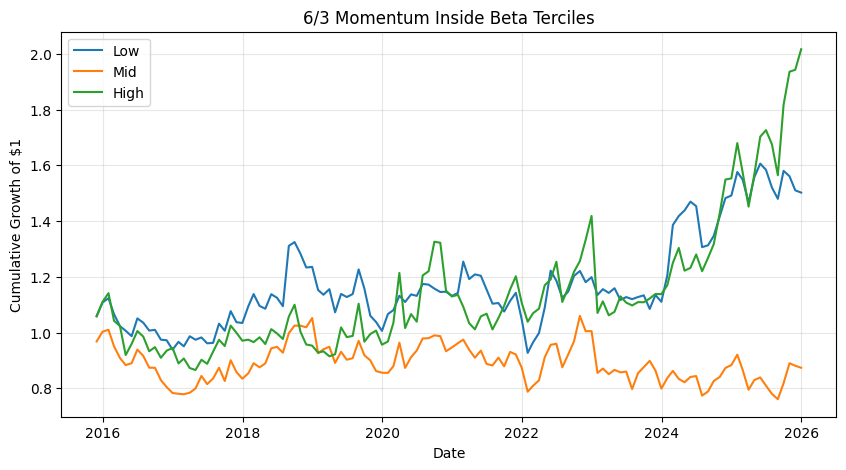


Saved outputs to ../results/


In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Table III: Beta-subsample test for 6/3 momentum
# - Load prices from ../data/sp500_prices.parquet
# - Estimate trailing betas using past 12 months
# - At each formation month, split stocks into Low/Mid/High beta terciles
# - Run 6/3 momentum within each tercile
# - Hold each subportfolio for 3 months with overlapping portfolios
# ============================================================

# ----------------------------
# 1) Load data
# ----------------------------
prices = pd.read_parquet("../data/sp500_prices.parquet")

daily_close = prices["Close"].copy().sort_index()
daily_close = daily_close.dropna(axis=1, how="all")

monthly_close = daily_close.resample("ME").last()
monthly_close = monthly_close.dropna(axis=1, how="all")

monthly_ret = monthly_close.pct_change(fill_method=None)

# Equal-weighted market proxy
market_ret = monthly_ret.mean(axis=1, skipna=True).rename("market_ret")

print("monthly_close shape:", monthly_close.shape)
print("monthly_ret shape:", monthly_ret.shape)
print("market_ret shape:", market_ret.shape)
print("monthly_close index head:", monthly_close.index[:5])
print("monthly_ret index head:", monthly_ret.index[:5])

# ----------------------------
# 2) Helpers
# ----------------------------
def compute_formation_signal(monthly_close: pd.DataFrame, J: int = 6) -> pd.DataFrame:
    """
    Past J-month cumulative return used for ranking.
    signal[t] = P_t / P_{t-J} - 1
    """
    return monthly_close.pct_change(periods=J, fill_method=None)


def assign_deciles(signal_row: pd.Series, n_deciles: int = 10) -> pd.Series:
    """
    1 = losers decile
    10 = winners decile
    """
    x = signal_row.dropna()
    if len(x) < n_deciles:
        return pd.Series(dtype="int64")

    ranks = x.rank(method="first")
    labels = pd.qcut(ranks, n_deciles, labels=False) + 1
    return pd.Series(labels.astype(int), index=x.index)


def performance_summary(r: pd.Series, periods_per_year: int = 12, nw_lags: int = 5) -> pd.Series:
    """
    Monthly return series summary.
    """
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    mean_m = r.mean()
    vol_m = r.std(ddof=1)
    ann_ret = (1 + mean_m) ** periods_per_year - 1
    ann_vol = vol_m * np.sqrt(periods_per_year)
    sharpe = (mean_m / vol_m) * np.sqrt(periods_per_year) if vol_m > 0 else np.nan

    X = np.ones((len(r), 1))
    nw = sm.OLS(r.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})

    return pd.Series(
        {
            "mean_monthly": mean_m,
            "ann_return_approx": ann_ret,
            "ann_vol": ann_vol,
            "sharpe": sharpe,
            "nw_tstat_mean": nw.tvalues[0],
            "nw_pvalue_mean": nw.pvalues[0],
            "n_obs": len(r),
        }
    )


def capm_summary(r: pd.Series, market_ret: pd.Series, nw_lags: int = 5) -> pd.Series:
    """
    CAPM regression with HAC/Newey-West SE:
        r_t = alpha + beta * market_t + eps_t
    """
    df = pd.concat([r.rename("r"), market_ret.rename("m")], axis=1).dropna()
    if len(df) < 10:
        return pd.Series(dtype=float)

    X = sm.add_constant(df["m"])
    model = sm.OLS(df["r"], X).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})

    return pd.Series(
        {
            "alpha": model.params["const"],
            "beta": model.params["m"],
            "t_alpha": model.tvalues["const"],
            "t_beta": model.tvalues["m"],
            "p_alpha": model.pvalues["const"],
            "p_beta": model.pvalues["m"],
            "n_obs": int(model.nobs),
        }
    )


def estimate_trailing_beta_panel(
    monthly_ret: pd.DataFrame,
    market_ret: pd.Series,
    lookback: int = 12,
    min_obs: int = 8,
) -> pd.DataFrame:
    """
    For each month t, estimate each stock's beta using returns from
    the previous `lookback` months, excluding month t itself.
    """
    dates = monthly_ret.index
    tickers = monthly_ret.columns
    beta_panel = pd.DataFrame(index=dates, columns=tickers, dtype=float)

    for i, dt in enumerate(dates):
        start = max(0, i - lookback)
        if start >= i:
            continue

        window_r = monthly_ret.iloc[start:i]
        window_m = market_ret.iloc[start:i]

        for tkr in tickers:
            df = pd.concat([window_r[tkr], window_m], axis=1).dropna()
            if len(df) < min_obs:
                continue

            m = df.iloc[:, 1].values
            r = df.iloc[:, 0].values

            var_m = np.var(m, ddof=1)
            if pd.isna(var_m) or var_m == 0:
                continue

            cov = np.cov(r, m, ddof=1)[0, 1]
            beta_panel.loc[dt, tkr] = cov / var_m

    return beta_panel


def make_beta_tercile_memberships(beta_panel: pd.DataFrame) -> dict:
    """
    For each formation date, split available stocks into:
    Low / Mid / High beta terciles.
    Returns:
        memberships[group_name][date] = list_of_tickers
    """
    memberships = {"Low": {}, "Mid": {}, "High": {}}

    for dt in beta_panel.index:
        beta_row = beta_panel.loc[dt].dropna()
        if len(beta_row) < 3:
            continue

        ranks = beta_row.rank(method="first")
        terciles = pd.qcut(ranks, 3, labels=False) + 1  # 1,2,3

        memberships["Low"][dt] = terciles[terciles == 1].index.tolist()
        memberships["Mid"][dt] = terciles[terciles == 2].index.tolist()
        memberships["High"][dt] = terciles[terciles == 3].index.tolist()

    return memberships


def momentum_backtest_with_membership(
    monthly_close: pd.DataFrame,
    monthly_ret: pd.DataFrame,
    membership_by_date: dict,
    J: int = 6,
    K: int = 3,
    n_deciles: int = 10,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run overlapping momentum inside a fixed cross-sectional membership
    (e.g. Low-beta group only).

    Returns
    -------
    strategy_df: monthly winner/loser/long-short returns
    holdings_df : formation-date holdings
    """
    signal = compute_formation_signal(monthly_close, J=J)
    dates = monthly_close.index

    subportfolios = []
    holdings_rows = []

    for formation_pos, dt in enumerate(dates):
        universe = membership_by_date.get(dt, [])
        if len(universe) < n_deciles:
            continue

        row = signal.loc[dt, universe].dropna()
        if len(row) < n_deciles:
            continue

        deciles = assign_deciles(row, n_deciles=n_deciles)
        if deciles.empty:
            continue

        winners = deciles[deciles == n_deciles].index.tolist()
        losers = deciles[deciles == 1].index.tolist()

        start_pos = formation_pos + 1
        end_pos = min(formation_pos + K, len(dates) - 1)
        if start_pos >= len(dates):
            continue

        subportfolios.append(
            {
                "formation_date": dt,
                "start_pos": start_pos,
                "end_pos": end_pos,
                "winners": winners,
                "losers": losers,
            }
        )

        holdings_rows.append(
            {
                "formation_date": dt,
                "n_universe": len(universe),
                "n_winners": len(winners),
                "n_losers": len(losers),
                "winners": winners,
                "losers": losers,
            }
        )

    out = []
    for t_pos, dt in enumerate(dates):
        active_winner_rets = []
        active_loser_rets = []

        r = monthly_ret.loc[dt]

        for sp in subportfolios:
            if sp["start_pos"] <= t_pos <= sp["end_pos"]:
                w = sp["winners"]
                l = sp["losers"]

                wret = r[w].dropna().mean() if len(w) > 0 else np.nan
                lret = r[l].dropna().mean() if len(l) > 0 else np.nan

                if pd.notna(wret) and pd.notna(lret):
                    active_winner_rets.append(wret)
                    active_loser_rets.append(lret)

        if len(active_winner_rets) == 0:
            continue

        winner_ret = float(np.mean(active_winner_rets))
        loser_ret = float(np.mean(active_loser_rets))
        ls_ret = winner_ret - loser_ret

        out.append(
            {
                "date": dt,
                "winner_ret": winner_ret,
                "loser_ret": loser_ret,
                "long_short_ret": ls_ret,
                "n_active_subportfolios": len(active_winner_rets),
            }
        )

    strategy_df = pd.DataFrame(out).set_index("date")
    holdings_df = pd.DataFrame(holdings_rows).set_index("formation_date")
    return strategy_df, holdings_df


# ----------------------------
# 3) Estimate trailing betas
# ----------------------------
beta_panel = estimate_trailing_beta_panel(
    monthly_ret=monthly_ret,
    market_ret=market_ret,
    lookback=12,
    min_obs=8,
)

print("\nBeta panel head:")
display(beta_panel.head())

sample_dt = beta_panel.dropna(how="all").index[20]
print("\nCross-sectional beta snapshot:")
print(sample_dt)
display(beta_panel.loc[sample_dt].dropna().describe())

# ----------------------------
# 4) Build beta tercile memberships
# ----------------------------
beta_memberships = make_beta_tercile_memberships(beta_panel)

print("\nMembership dates:")
print("Low:", len(beta_memberships["Low"]))
print("Mid:", len(beta_memberships["Mid"]))
print("High:", len(beta_memberships["High"]))

# ----------------------------
# 5) Run 6/3 momentum inside each beta tercile
# ----------------------------
group_results = {}
summary_rows = []

for group_name in ["Low", "Mid", "High"]:
    bt_g, holdings_g = momentum_backtest_with_membership(
        monthly_close=monthly_close,
        monthly_ret=monthly_ret,
        membership_by_date=beta_memberships[group_name],
        J=6,
        K=3,
        n_deciles=10,
    )

    group_results[group_name] = {
        "bt": bt_g,
        "holdings": holdings_g,
    }

    if len(bt_g) == 0:
        continue

    perf = performance_summary(bt_g["long_short_ret"])
    capm = capm_summary(bt_g["long_short_ret"], market_ret)

    row = {
        "group": group_name,
        "mean_monthly_ls": perf["mean_monthly"],
        "nw_tstat_mean_ls": perf["nw_tstat_mean"],
        "ann_return_approx": perf["ann_return_approx"],
        "sharpe": perf["sharpe"],
        "capm_alpha": capm["alpha"],
        "capm_t_alpha": capm["t_alpha"],
        "capm_beta": capm["beta"],
        "n_obs": perf["n_obs"],
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("group")

print("\n=== Beta-subsample summary (6/3 momentum) ===")
display(summary_df.round(4))

# ----------------------------
# 6) Decile averages inside each beta group
# ----------------------------
for group_name in ["Low", "Mid", "High"]:
    bt_g = group_results[group_name]["bt"]
    if len(bt_g) == 0:
        continue

    print(f"\n--- {group_name} beta group: 6/3 momentum ---")
    display(performance_summary(bt_g["long_short_ret"]).round(4))
    display(bt_g[["winner_ret", "loser_ret", "long_short_ret"]].mean().to_frame("mean_return").round(4))

# ----------------------------
# 7) Plot long-short cumulative curves
# ----------------------------
plt.figure(figsize=(10, 5))
for group_name in ["Low", "Mid", "High"]:
    bt_g = group_results[group_name]["bt"]
    if len(bt_g) == 0:
        continue
    eq = (1 + bt_g["long_short_ret"].fillna(0)).cumprod()
    plt.plot(eq.index, eq.values, label=group_name)

plt.title("6/3 Momentum Inside Beta Terciles")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------
# 8) Optional: save outputs
# ----------------------------
Path("../results").mkdir(exist_ok=True)
summary_df.to_csv("../results/table3_beta_subsample_summary.csv")
beta_panel.to_csv("../results/beta_panel.csv")
for group_name in ["Low", "Mid", "High"]:
    bt_g = group_results[group_name]["bt"]
    holdings_g = group_results[group_name]["holdings"]
    if len(bt_g) > 0:
        bt_g.to_csv(f"../results/{group_name.lower()}_beta_63_bt.csv")
    if len(holdings_g) > 0:
        holdings_g.to_csv(f"../results/{group_name.lower()}_beta_63_holdings.csv")

print("\nSaved outputs to ../results/")
